<a href="https://colab.research.google.com/github/znr6s28ynr-maker/Econometrics-Work/blob/main/ECON_6550_Google_Colab_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Showing the Matrix Representation of the Linear Regression Model is Equal to its Arbitrary Observation Representation:

We begin with:
\begin{equation}
\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}
\end{equation}

where:

\begin{equation}
\mathbf{Y} =
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix},
\quad
\mathbf{X} =
\begin{pmatrix}
1 & x_{1,1} & x_{2,1} & \dots & x_{k,1} \\
1 & x_{1,2} & x_{2,2} & \dots & x_{k,1} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{1,n} & x_{2,n} & \dots & x_{k,n}
\end{pmatrix},
\quad
\boldsymbol{\beta} =
\begin{pmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_k
\end{pmatrix},
\quad
\boldsymbol{\epsilon} =
\begin{pmatrix}
\epsilon_1 \\
\epsilon_2 \\
\vdots \\
\epsilon_n
\end{pmatrix}
\end{equation}

Then:

\begin{equation}
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
=
\begin{pmatrix}
1 & x_{1,1} & x_{2,1} & \dots & x_{k,1} \\
1 & x_{1,2} & x_{2,2} & \dots & x_{k,1} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{1,n} & x_{2,n} & \dots & x_{k,n}
\end{pmatrix}
\begin{pmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_k
\end{pmatrix}
+
\begin{pmatrix}
\epsilon_1 \\
\epsilon_2 \\
\vdots \\
\epsilon_n
\end{pmatrix}
\end{equation}

Multiplying matrices **X** and **$\beta$**:

\begin{equation}
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
=
\begin{pmatrix}
\beta_0 + \beta_1x_{1,1} + \beta_2x_{2,1} + \dots + \beta_kx_{k,1} \\
\beta_0 + \beta_1x_{1,2} + \beta_2x_{2,2} + \dots + \beta_kx_{k,1} \\
\vdots\ \ +\ \ \vdots\ \ +\ \ \vdots\ \ +\ \ \ddots\ \ +\ \ \vdots \\
\beta_0 + \beta_1x_{1,n} + \beta_2x_{2,n} + \dots + \beta_kx_{k,n}
\end{pmatrix}
+
\begin{pmatrix}
\epsilon_1 \\
\epsilon_2 \\
\vdots \\
\epsilon_n
\end{pmatrix}
\end{equation}


Replacing vector indeces with $i$:


\begin{equation}
y_i
=
𝛽_0 + 𝛽_1x_{1,i} + 𝛽_2x_{2,i} + ... + 𝛽_kx_{k,i}
+
\epsilon_i
\end{equation}




##Effect of Starbucks Barista Budget on Profit (Nonlinear Regression Model Example)

In this scenario, the model attempts to describe how manipulation of the "barista budget," (by which I mean money spent on salaries, benefits, uniforms, incentives, etc. for barista employees) affects store profit.

<br>

The **independent variable** would be the barista budget, and the **dependent variable** would be profit.

At first, the amount of money allocated to the barista budget will increase profit, because there will be more baristas to handle orders, which means that the store can sell more faster. Wait times will be reduced and happier employees will keep customers coming back. But after a certain point, returns on this investment will diminish and eventually peak, after which time a larger barista budget will begin to cut more and more into the profits.

<br>

The theoretical model would look like this:

<br>

$Profit = \beta_0 + \beta_1BaristaBudget + \beta_2BaristaBudget^2 + \epsilon$

<br>

By placing numerical values in place of the betas, we might see something like this (with a negative in front of the squared variable so that we get a parabola that opens in the correct direction):

<br>

$Profit = 20 + 8BaristaBudget - (0.4BaristaBudget)^2 + \epsilon$

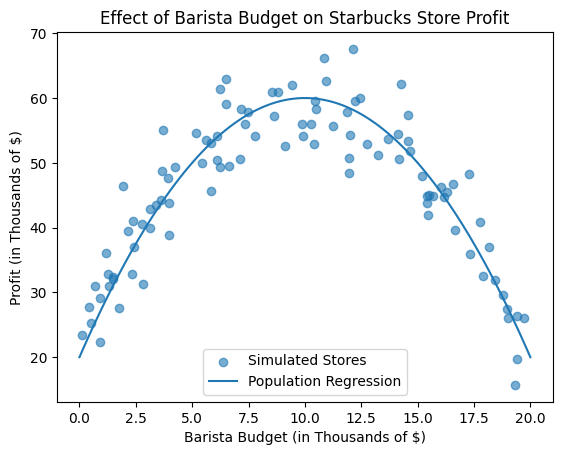

In [ ]:
# Define the population regression parameters
beta_0 = 20    # (0 - 20 Barista budget range)
beta_1 = 8     # Coefficient for barista budget
beta_2 = -0.4  # Coefficient for squared barista budget

# Simulate data for 100 stores
np.random.seed(42)
n = 100

# Random barista budgets between $0k and $20k
B_data = np.random.uniform(0, 20, n)

# Population regression function evaluated at each store
expected_profit = beta_0 + beta_1 * B_data + beta_2 * B_data**2

# Random error term
epsilon = np.random.normal(0, 5, n)

# Observed store profits
profit_data = expected_profit + epsilon

# Values for drawing the smooth population regression curve
B = np.linspace(0, 20, 100)
profit = beta_0 + beta_1 * B + beta_2 * B**2

# Plot simulated observations
plt.scatter(B_data, profit_data, alpha=0.6, label='Simulated Stores')

# Plot population regression line
plt.plot(B, profit, label='Population Regression')

plt.xlabel('Barista Budget (in Thousands of $)')
plt.ylabel('Profit (in Thousands of $)')
plt.title('Effect of Barista Budget on Starbucks Store Profit')
plt.legend()

plt.show()

##Derivative of Regression Model

Taking the derivative of the regression model

<br>

$Profit = 20 + 8BaristaBudget - (0.4BaristaBudget)^2 + \epsilon$

<br>

gives:

<br>

$$
\frac{dProfit}{dBaristaBudget} = 8 - 0.8BaristaBudget
$$

<br>

This derivative represents the "marginal effect of spending on the returns" (I looked up how to state this in Econometric terms. I wanted to call it the "rate of return", but I guess that's not exactly how to describe what this equation represents).

The derivative of any equation is a representation of the slope of the equation at all points. Here, it represents how steeply profits rise or fall as we increase or decrease the barista budget. As we get close to the maximum of the regression curve, approaching from the left, the amount of an effect that increasing the budget will have (the rate) decreases. Then it peaks at the apex, and afterwards budget increase begins to have a negative effect on profits until it could ultimately fully cancel them out and become negative.

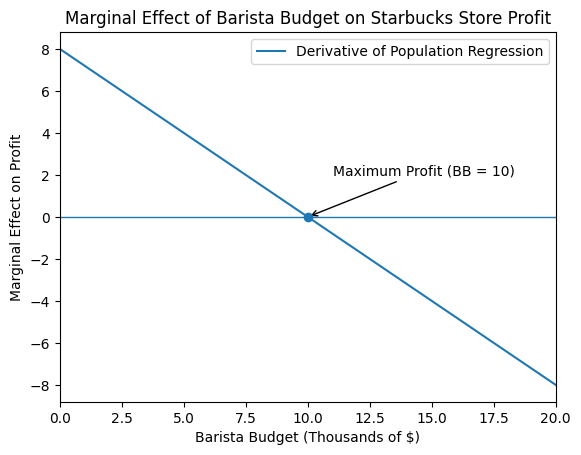

In [ ]:
# Derivative function of population regression curve
B = np.linspace(0, 20, 100)
marginal_effect = 8 - 0.8 * B

# Plot derivative function
plt.plot(B, marginal_effect,
         label='Derivative of Population Regression')

# Show horizontal axis at marginal effect = 0
plt.axhline(y=0, linewidth=1)

# Mark B = 10, where marginal effect = 0
plt.scatter(10, 0, zorder=5)

# Label the point
plt.annotate(
    'Maximum Profit (BB = 10)',
    xy=(10, 0),
    xytext=(11, 2),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel('Barista Budget (Thousands of $)')
plt.ylabel('Marginal Effect on Profit')
plt.title('Marginal Effect of Barista Budget on Starbucks Store Profit')
plt.xlim(0, 20)
plt.legend()

plt.show()

##Starbucks Barista Salaries: Entry level and Manager

This next model is a representation of yearly Starbucks full-time barista salaries.

<br>

The independent variables include:


*   **Continuous variable:** hourly rate (multiplied by hours worked)
*   **Categorical dummy variable:** Christmas bonus (included when value is 1 and not when value is 0).


<br>

The model would look like this:

<br>

$Salary = \beta_1Hours + \beta_2Bonus + \epsilon$

<br>

Setting $\beta_1$ to 15 (dollars) and $\beta_2$ to 5000 (dollars):

<br>

$Salary = 15Hours + 5000Bonus + \epsilon$

<br> The error term could represent unobserved factors affecting salary, including tips, unpaid time off, overtime, etc.

Estimated intercept (No Bonus, correct model): 442.07927220720376
Estimated slope for Hours (correct model): 14.775066509068253
Estimated Bonus intercept shift (correct model): 5037.953869382728
Estimated intercept (incorrect model): 2961.0562068985673
Estimated slope for hours (incorrect model): 14.775066509068253


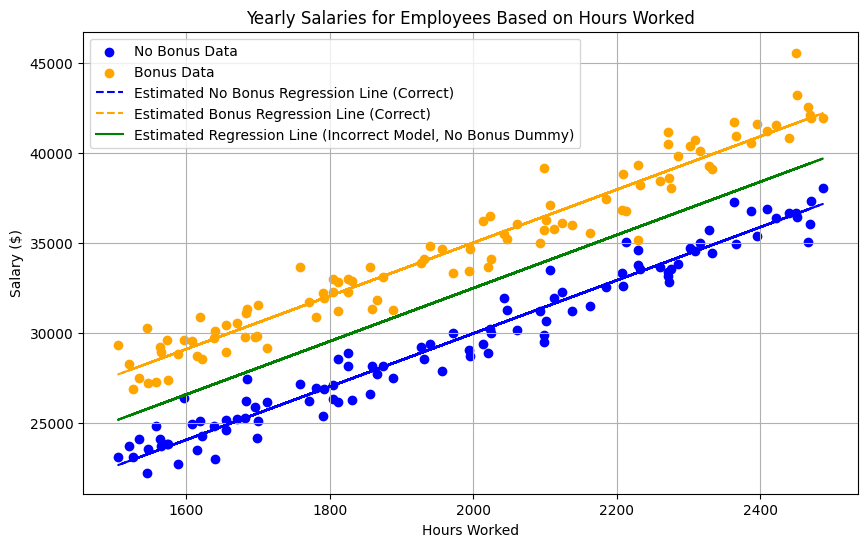

In [2]:
from sklearn.linear_model import LinearRegression

# Set seed for reproducibility
np.random.seed(42)

# Number of observations
n = 100

# Simulate hours worked
hours = np.random.uniform(1500, 2500, n)  # Between 1500 and 2500 hours worked

# Define population coefficients
beta_1 = 15  # slope with respect to salary
beta_2 = 5000 # Difference for Christmas bonus

# Error term
epsilon_no_bonus = np.random.normal(0, 1000, n)  # Random noise for employees not getting bonus
epsilon_bonus = np.random.normal(0, 1000, n)  # Random noise for employees getting bonus

# Simulate salary for employees not getting bonus (Bonus = 0)
salary_no_bonus = beta_1 * hours + epsilon_no_bonus

# Simulate salary for employees getting bonus (Bonus = 1)
salary_bonus = beta_1 * hours + beta_2 + epsilon_bonus

# Combine data for regression
hours_combined = np.concatenate([hours, hours])
salaries_combined = np.concatenate([salary_no_bonus, salary_bonus])
employees_combined = np.array([0] * n + [1] * n)  # 0 for no bonus, 1 for bonus

# Create a DataFrame for regression
df = pd.DataFrame({
    'Hours': hours_combined,
    'Employees': employees_combined,
    'Salary': salaries_combined
})

# Fit the correct model with hours and a dummy for bonus
X_correct = df[['Hours', 'Employees']]
y = df['Salary']
model_correct = LinearRegression().fit(X_correct, y)

# Get the estimated coefficients for the correct model
intercept_correct = model_correct.intercept_
beta_1_estimated_correct = model_correct.coef_[0]  # Slope for hours
beta_2_estimated_correct = model_correct.coef_[1]  # Shift for bonus

# Fit the incorrect model (without the bonus dummy)
X_incorrect = df[['Hours']]  # Only use hours, no bonus dummy
model_incorrect = LinearRegression().fit(X_incorrect, y)

# Get the estimated coefficients for the incorrect model
intercept_incorrect = model_incorrect.intercept_
beta_1_estimated_incorrect = model_incorrect.coef_[0]

# Print the estimated coefficients
print(f"Estimated intercept (No Bonus, correct model): {intercept_correct}")
print(f"Estimated slope for Hours (correct model): {beta_1_estimated_correct}")
print(f"Estimated Bonus intercept shift (correct model): {beta_2_estimated_correct}")
print(f"Estimated intercept (incorrect model): {intercept_incorrect}")
print(f"Estimated slope for hours (incorrect model): {beta_1_estimated_incorrect}")

# Plotting the data
plt.figure(figsize=(10, 6))
plt.scatter(hours, salary_no_bonus, color='blue', label='No Bonus Data')
plt.scatter(hours, salary_bonus, color='orange', label='Bonus Data')

# Plot the estimated regression lines for the correct model
plt.plot(hours, intercept_correct + beta_1_estimated_correct * hours, color='blue', linestyle='--', label='Estimated No Bonus Regression Line (Correct)')
plt.plot(hours, (intercept_correct + beta_2_estimated_correct) + beta_1_estimated_correct * hours, color='orange', linestyle='--', label='Estimated Bonus Regression Line (Correct)')

# Plot the estimated regression line for the incorrect model
plt.plot(hours, intercept_incorrect + beta_1_estimated_incorrect * hours, color='green', linestyle='-', label='Estimated Regression Line (Incorrect Model, No Bonus Dummy)')

# Adding labels and title
plt.xlabel('Hours Worked')
plt.ylabel('Salary ($)')
plt.title('Yearly Salaries for Employees Based on Hours Worked')
plt.legend()
plt.grid(True)
plt.show()

In the above plot, the green line represents a regression line that too vaguely conceptualizes the data, since it ignores the fact that one of the variables is categorical. A categorical variable, especially one that is binary, allows us to separate the data according to whether that feature is present or not.

Taking this distinguishing factor into account is very helpful to understanding actual variation in employee salaries. If we ignore that one of the variables is categorical, we might think that variation in salaries is much larger than it actually is. When we separate the data according to the presence or absence of this variable, we actually see that salary variation displays less erraticism than we might initially surmise.

##Slope Coefficient Exploration

In an equation like:

\begin{equation}
Y_i
=
𝛽_0 + 𝛽_1x_i
+
\epsilon_i
\end{equation}

where $x_i$ is a binary categorical variable, the population means of the parameters could be expressed as:  

\begin{equation}
E[Y_i|x_i]
=
E[𝛽_0 + 𝛽_1x_i
+ \epsilon_i]
\end{equation}


The expected value of the residual should by definition be 0, so

When $x_i = 1$:

\begin{equation}
E[Y_i|x_i = 1]
=
𝛽_0 + 𝛽_1
\end{equation}

When $x_i = 0$:

\begin{equation}
E[Y_i|x_1 = 0]
=
𝛽_0
\end{equation}

Taking the difference:

\begin{equation}
E[Y_i|x_i = 1]
-
E[Y_i|x_i = 0]
\end{equation}

\begin{equation}
𝛽_0 + 𝛽_1
-
𝛽_0
=
𝛽_1
\end{equation}

The difference between the two population means is $\beta_1$, which is the coefficient of the independent catagorical variable.
